# Laptop Price Classification & Model Comparison

This notebook provides a comprehensive workflow for building, evaluating, and saving machine learning models to classify laptop prices into **Low**, **Medium**, and **High** categories.

## Objectives
1.  **Data Loading**: Load the cleaned laptop dataset.
2.  **Exploratory Data Analysis (EDA)**: Understand the data distribution and key features.
3.  **Preprocessing**: specific handling for categorical and numerical features.
4.  **Model Training**: Train multiple classifiers (Logistic Regression, Decision Tree, KNN, Naive Bayes, Random Forest, XGBoost).
5.  **Evaluation**: Compare models using Accuracy, Precision, Recall, F1-Score, and MCC.
6.  **Model Saving**: Consolidate best performing models into a single file for deployment.

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import gdown
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn & Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

# Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Data Loading
We load the dataset `laptop_data_cleaned.csv`. If it doesn't exist locally, we download it from Google Drive.

In [2]:
file_name = "laptop_data_cleaned.csv"
if not os.path.exists(file_name):
    direct_download_url = 'https://drive.google.com/uc?id=1W5Hgc8HTOm1ShOS0Bt_0Dwtq1scS5HmV'
    print(f"Downloading '{file_name}' from Google Drive...")
    gdown.download(direct_download_url, output=file_name, quiet=False)
else:
    print(f"'{file_name}' already exists locally.")

df = pd.read_csv(file_name)
print(f"Dataset Shape: {df.shape}")
df.head()

'laptop_data_cleaned.csv' already exists locally.
Dataset Shape: (1273, 13)


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


## 2. Target Variable Engineering
The original dataset contains a continuous `Price` variable. For this classification task, we bin the prices into three categories: **Low**, **Medium**, and **High** using quantiles.

- **Low**: Bottom 33% of prices
- **Medium**: Middle 33% of prices
- **High**: Top 33% of prices

Price_Category
Low       425
Medium    424
High      424
Name: count, dtype: int64


/var/folders/m2/5612jdhn69bc7ss87lhtw90m0000gn/T/ipykernel_32312/647464950.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Price_Category", data=df, palette="viridis")


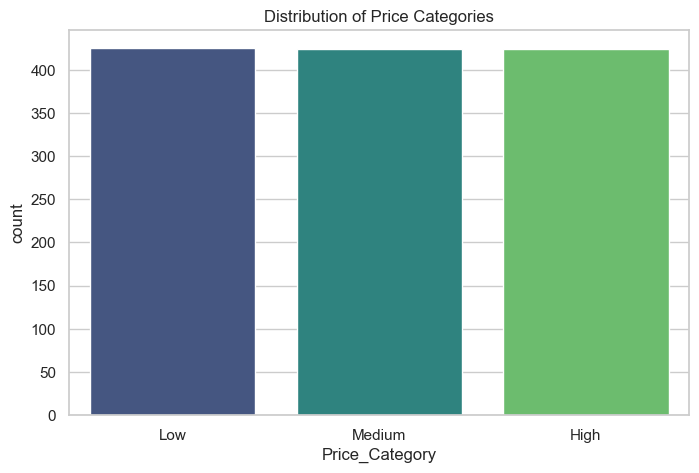

In [3]:
# Quantile binning
df["Price_Category"] = pd.qcut(
    df["Price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Verify distribution
print(df["Price_Category"].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(x="Price_Category", data=df, palette="viridis")
plt.title("Distribution of Price Categories")
plt.show()

## 3. Data Preprocessing
We separate features (X) and target (y), and define a preprocessing pipeline:
- **Numerical Columns**: Standard Scaler
- **Categorical Columns**: One-Hot Encoding (handling unknown categories)

In [4]:
# Split Features & Target
X = df.drop(["Price", "Price_Category"], axis=1)
y = df["Price_Category"]

# Identify columns
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print(f"Categorical Features: {list(categorical_cols)}")
print(f"Numerical Features: {list(numerical_cols)}")

# Define Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

Categorical Features: ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']
Numerical Features: ['Ram', 'Weight', 'TouchScreen', 'Ips', 'Ppi', 'HDD', 'SSD']


In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

Training Set: (1018, 12)
Test Set: (255, 12)


## 4. Model Training & Evaluation
We define a dictionary of models to train. XGBoost requires special handling for label encoding.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

results = []
all_pipelines = {}
original_categories = y.cat.categories

print("Starting Training Loop...")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Create Pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    # Train & Predict
    if name == "XGBoost":
        # XGBoost need separate label encoding for target
        y_train_encoded = y_train.cat.codes
        pipeline.fit(X_train, y_train_encoded)
        
        y_pred_numeric = pipeline.predict(X_test)
        # Decode predictions back to labels
        y_pred = original_categories[y_pred_numeric]
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
    
    # Store Pipeline
    all_pipelines[name] = pipeline
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "MCC": mcc
    })

print("Training Complete!")

Starting Training Loop...
Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Naive Bayes...
Training Random Forest...
Training XGBoost...
Training Complete!


## 5. View Results
A comparison table of model performance.

                 Model  Accuracy  Precision    Recall  F1 Score       MCC
5              XGBoost  0.874510   0.877070  0.874510  0.875264  0.812233
4        Random Forest  0.847059   0.853824  0.847059  0.849092  0.771711
0  Logistic Regression  0.807843   0.823673  0.807843  0.811564  0.715855
1        Decision Tree  0.807843   0.815981  0.807843  0.809991  0.713297
2                  KNN  0.803922   0.811672  0.803922  0.806139  0.707254
3          Naive Bayes  0.513725   0.603149  0.513725  0.473070  0.306403


/var/folders/m2/5612jdhn69bc7ss87lhtw90m0000gn/T/ipykernel_32312/1166232537.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1 Score", y="Model", data=results_df, palette="magma")


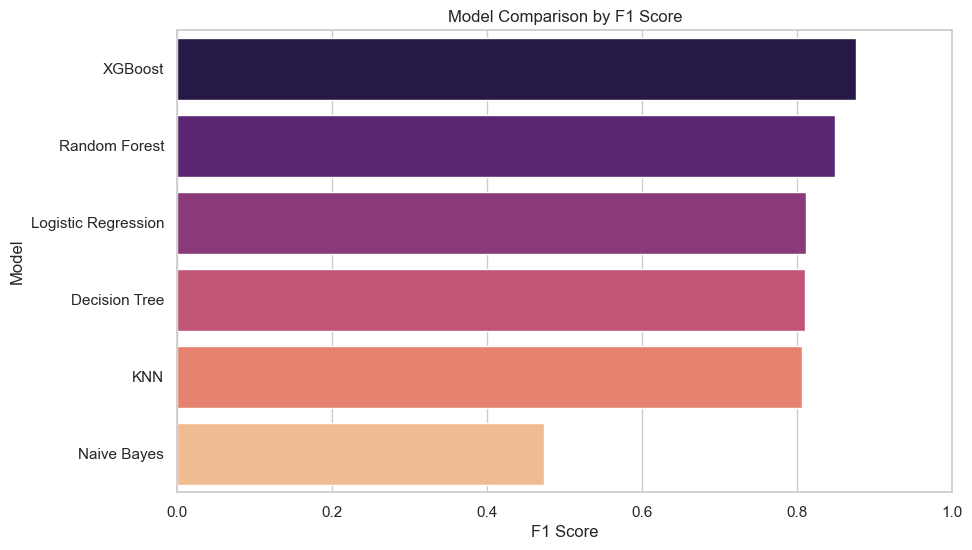

In [7]:
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print(results_df)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x="F1 Score", y="Model", data=results_df, palette="magma")
plt.title("Model Comparison by F1 Score")
plt.xlim(0, 1.0)
plt.show()

## 6. Saving Models
We save all trained pipelines into a single Dictionary file `all_models.pkl`. This dictionary allows us to easily access any model by name during deployment.

In [8]:
model_path = "all_models.pkl"
joblib.dump(all_pipelines, model_path)
print(f"\nAll pipelines saved to {model_path}!")

# Example of how to load back
print("\n--- Verification: Loading back Random Forest ---")
loaded_models = joblib.load(model_path)
rf_loaded = loaded_models["Random Forest"]
sample_pred = rf_loaded.predict(X_test.iloc[:1])
print(f"Sample Prediction: {sample_pred[0]}")


All pipelines saved to all_models.pkl!

--- Verification: Loading back Random Forest ---
Sample Prediction: High
